# Computer Vision Tasks (14-june) 

# TASK - 1  ( Implementation of Multiple Image Filters using OpenCV )

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

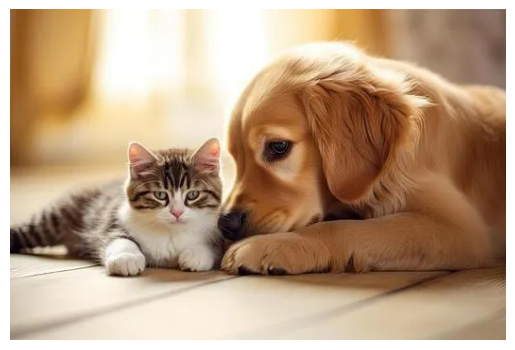

In [2]:
picture = cv2.imread("cat-dog.jpeg")
picture_rgb = cv2.cvtColor(picture, cv2.COLOR_BGR2RGB)
plt.imshow(picture_rgb)
plt.axis("off")
plt.show()

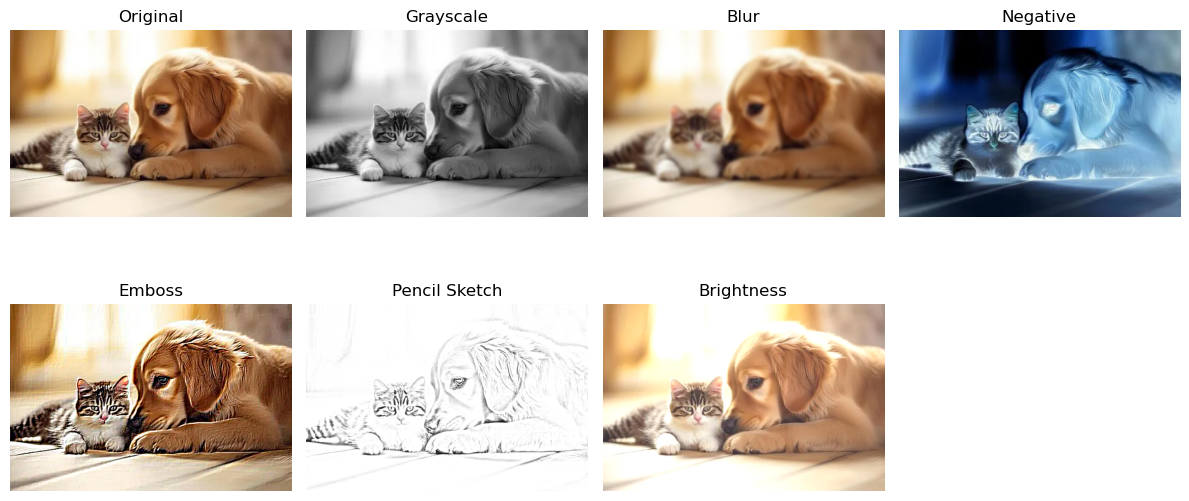

In [3]:
gray = cv2.cvtColor(picture, cv2.COLOR_RGB2GRAY)

blur = cv2.GaussianBlur(picture_rgb, (15,15), 0)

negative = cv2.bitwise_not(picture_rgb)

kernel = np.array([[-2,-1,0],[-1,1,1],[0,1,2]])

emboss = cv2.filter2D(picture_rgb, -1, kernel)

inv = 255 - gray
blur_sketch = cv2.GaussianBlur(inv, (21,21), 0)
pencil = cv2.divide(gray, 255-blur_sketch, scale=256)

bright = cv2.convertScaleAbs(picture_rgb, alpha=1, beta=50)

# Display
images = [("Original", picture_rgb),("Grayscale", gray),("Blur", blur),("Negative", negative),("Emboss", emboss),("Pencil Sketch", pencil),("Brightness", bright)]

plt.figure(figsize=(12,6))

for i, (title, picture) in enumerate(images, 1):

    plt.subplot(2,4,i)
    if len(picture.shape) == 2:
        plt.imshow(picture, cmap="gray")
    else:
        plt.imshow(picture)

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

# TASK - 2 ( Video Cropping Using OpenCV )

In [4]:
import cv2
import numpy as np
cap = cv2.VideoCapture("video.mp4")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    crop1 = frame[0:360, 0:426]
    crop2 = frame[0:360, 426:852]
    crop3 = frame[360:720, 0:426]
    crop4 = frame[360:720, 426:852]

    # Same size
    crop1 = cv2.resize(crop1, (400,250))
    crop2 = cv2.resize(crop2, (400,250))
    crop3 = cv2.resize(crop3, (400,250))
    crop4 = cv2.resize(crop4, (400,250))

    # White gap
    gap_v = np.ones((250,20,3), dtype=np.uint8) * 255
    gap_h = np.ones((20,820,3), dtype=np.uint8) * 255

    row1 = np.hstack((crop1, gap_v, crop2))
    row2 = np.hstack((crop3, gap_v, crop4))

    final = np.vstack((row1, gap_h, row2))

    cv2.imshow("4 Cropped Video Regions", final)

    if cv2.waitKey(25) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

# TASK - 3 ( Displaying two videos in two boxes )

In [5]:
# METHOD - 1

import cv2

cap1 = cv2.VideoCapture("video1.mp4")
cap2 = cv2.VideoCapture("video2.mp4")

while True:

    ret1, frame1 = cap1.read()
    ret2, frame2 = cap2.read()

    if not ret1 or not ret2:
        break

    cv2.imshow("Video 1", frame1)
    cv2.imshow("Video 2", frame2)

    if cv2.waitKey(30) & 0xFF == 27:
        break

cap1.release()
cap2.release()

cv2.destroyAllWindows()

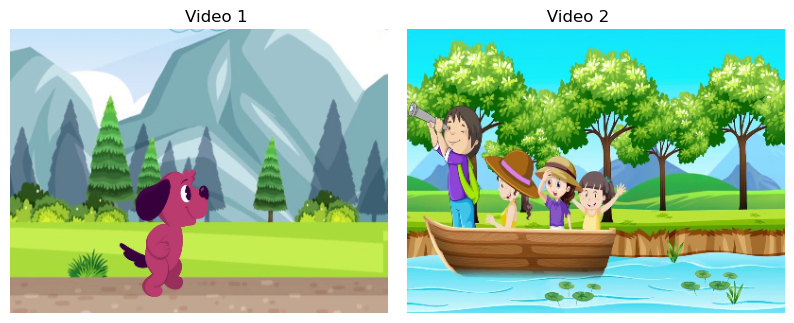

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

cap1 = cv2.VideoCapture("video1.mp4")
cap2 = cv2.VideoCapture("video2.mp4")

while True:

    ret1, frame1 = cap1.read()
    ret2, frame2 = cap2.read()

    if not ret1 or not ret2:
        break

    frame1 = cv2.resize(frame1, (400,300))
    frame2 = cv2.resize(frame2, (400,300))

    frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
    frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

    gap = np.ones((300, 20, 3), dtype=np.uint8) * 255
    
    final = np.hstack((frame1,gap, frame2))

    clear_output(wait=True)

    plt.figure(figsize=(10,5))
    plt.imshow(final)
    plt.title("Video 1                                                         Video 2")
    plt.axis("off")
    plt.show()

cap1.release()
cap2.release()

# TASK-4 (Interactive Image Cropping with Boundary Validation Using OpenCV)

Enter Height:  800
Enter Width:  900


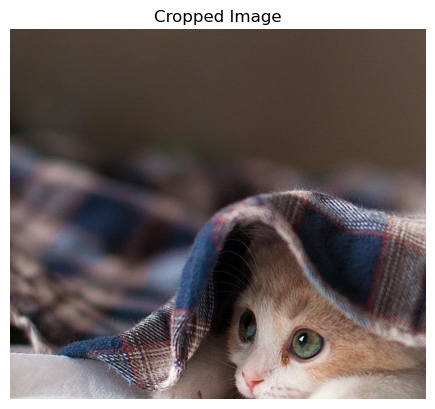

In [7]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("cat.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img.shape

height = int(input("Enter Height: "))
width = int(input("Enter Width: "))

if height > h or width > w:
    print("❌Crop size cannot exceed image dimensions!")
    print(f"Maximum Height = {h}")
    print(f"Maximum Width = {w}")

else:
    crop = img[:height, :width]

    plt.imshow(crop)
    plt.title("Cropped Image")
    plt.axis("off")
    plt.show()

# TASK-6 ( Menu Base )

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def image_filters():
    print("Task 1: Image Filters")

    picture = cv2.imread("cat-dog.jpeg")
    picture_rgb = cv2.cvtColor(picture, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(picture, cv2.COLOR_RGB2GRAY)

    blur = cv2.GaussianBlur(picture_rgb, (15,15), 0)

    negative = cv2.bitwise_not(picture_rgb)

    kernel = np.array([[-2,-1,0],[-1,1,1],[0,1,2]])

    emboss = cv2.filter2D(picture_rgb, -1, kernel)

    inv = 255 - gray
    blur_sketch = cv2.GaussianBlur(inv, (21,21), 0)
    pencil = cv2.divide(gray, 255-blur_sketch, scale=256)

    bright = cv2.convertScaleAbs(picture_rgb, alpha=1, beta=50)

    # Display
    images = [("Original", picture_rgb),("Grayscale", gray),("Blur", blur),("Negative", negative),("Emboss", emboss),("Pencil Sketch", pencil),("Brightness", bright)]

    plt.figure(figsize=(12,6))

    for i, (title, picture) in enumerate(images, 1):

        plt.subplot(2,4,i)
        if len(picture.shape) == 2:
            plt.imshow(picture, cmap="gray")
        else:
            plt.imshow(picture)

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [9]:
def video_cropping():
    print("Task 2: Video Cropping")

    cap = cv2.VideoCapture("video.mp4")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        crop1 = frame[0:360, 0:426]
        crop2 = frame[0:360, 426:852]
        crop3 = frame[360:720, 0:426]
        crop4 = frame[360:720, 426:852]

        # Same size
        crop1 = cv2.resize(crop1, (400,250))
        crop2 = cv2.resize(crop2, (400,250))
        crop3 = cv2.resize(crop3, (400,250))
        crop4 = cv2.resize(crop4, (400,250))

        # White gap
        gap_v = np.ones((250,20,3), dtype=np.uint8) * 255
        gap_h = np.ones((20,820,3), dtype=np.uint8) * 255

        row1 = np.hstack((crop1, gap_v, crop2))
        row2 = np.hstack((crop3, gap_v, crop4))

        final = np.vstack((row1, gap_h, row2))

        cv2.imshow("4 Cropped Video Regions", final)

        if cv2.waitKey(25) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [10]:
def two_video_display():
    print("Task 3: Two Video Display")

    from IPython.display import clear_output

    cap1 = cv2.VideoCapture("video1.mp4")
    cap2 = cv2.VideoCapture("video2.mp4")

    frame_count = 0
    max_frames = 200   # stop condition

    while True:

        ret1, frame1 = cap1.read()
        ret2, frame2 = cap2.read()

        if not ret1 or not ret2:
            break

        frame1 = cv2.resize(frame1, (400,300))
        frame2 = cv2.resize(frame2, (400,300))

        frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
        frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

        gap = np.ones((300, 20, 3), dtype=np.uint8) * 255

        final = np.hstack((frame1, gap, frame2))

        clear_output(wait=True)

        plt.figure(figsize=(10,5))
        plt.imshow(final)
        plt.axis("off")
        plt.show()

        frame_count += 1
        if frame_count >= max_frames:
            break

    cap1.release()
    cap2.release()
            

In [11]:
def image_cropping():
    print("Task 4: Image Cropping")

    img = cv2.imread("cat.jpg")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    height = int(input("Enter Height: "))
    width = int(input("Enter Width: "))

    if height > h or width > w:
        print("❌Crop size cannot exceed image dimensions!")
        print(f"Maximum Height = {h}")
        print(f"Maximum Width = {w}")

    else:
        crop = img[:height, :width]

        plt.imshow(crop)
        plt.title("Cropped Image")
        plt.axis("off")
        plt.show()

In [16]:
def activity_detection():
    print("5. Activity Detection")

    cap = cv2.VideoCapture(0)

    ret, frame1 = cap.read()
    ret, frame2 = cap.read()

    count = 0

    # fixed box (ROI)
    x1, y1, x2, y2 = 200, 150, 400, 350

    while True:

        diff = cv2.absdiff(frame1, frame2)
        gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5,5), 0)

        _, thresh = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)
        dilated = cv2.dilate(thresh, None, 2)

        contours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

        cv2.rectangle(frame1, (x1, y1), (x2, y2), (255,0,0), 2)

        for c in contours:

            if cv2.contourArea(c) < 1000:
                continue

            x, y, w, h = cv2.boundingRect(c)

            if x > x1 and y > y1 and x+w < x2 and y+h < y2:
                count = count + 1
                cv2.rectangle(frame1, (x,y), (x+w,y+h), (0,255,0), 2)

        cv2.putText(frame1, "Count: " + str(count), (50,50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

        cv2.imshow("Activity", frame1)

        frame1 = frame2
        ret, frame2 = cap.read()

        if not ret:
            break

        if cv2.waitKey(30) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

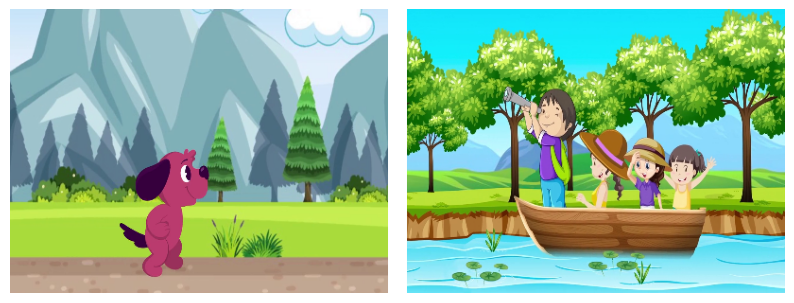


 COMPUTER VISION MENU 
1. Image Filters
2. Video Cropping
3. Two Video Display
4. Image Cropping
5. Activity Detection
6. Exit


Enter Choice:  4


Task 4: Image Cropping


Enter Height:  800
Enter Width:  900


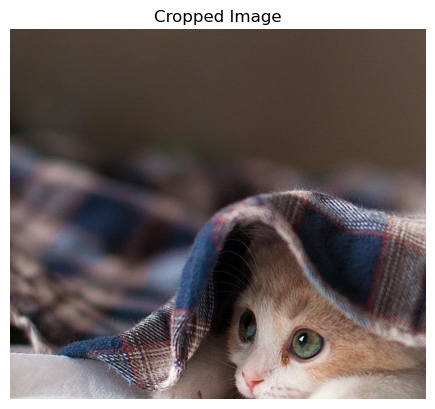


 COMPUTER VISION MENU 
1. Image Filters
2. Video Cropping
3. Two Video Display
4. Image Cropping
5. Activity Detection
6. Exit


Enter Choice:  5


5. Activity Detection

 COMPUTER VISION MENU 
1. Image Filters
2. Video Cropping
3. Two Video Display
4. Image Cropping
5. Activity Detection
6. Exit


Enter Choice:  6


Program Closed


In [17]:
while True:

    print("\n COMPUTER VISION MENU ")

    print("1. Image Filters")
    print("2. Video Cropping")
    print("3. Two Video Display")
    print("4. Image Cropping")
    print("5. Activity Detection")
    print("6. Exit")

    choice = int(input("Enter Choice: "))

    if choice == 1:
        image_filters()

    elif choice == 2:
        video_cropping()

    elif choice == 3:
        two_video_display()

    elif choice == 4:
        image_cropping()

    elif choice == 5:
        activity_detection()

    elif choice == 6:
        print("Program Closed")
        break

    else:
        print("Invalid Choice")